# Notebook: Core dynamics

A HORN unit is:

$$\ddot{x} + 2\zeta\omega\,\dot{x} + \omega^2 x = f(x, u), \qquad f(x,u) = W_{rec}\tanh(x) + W_{in}u$$

Here we check that `core.py` implements exactly that. 
Coupling is always off (`W_rec = 0`), making every unit a damped oscillator with a known answer.

The point is to establish that the physics are correct.

**Contents**

1. Free oscillation vs. the analytic solution
2. Damping regimes — under, critical, over
3. Impulse response
4. Sinusoidal drive and steady state
5. Resonance — amplitude and phase against drive frequency
6. A heterogeneous population as a filter bank
7. Why the integrator is semi-implicit

First let´s initialize libraries and check the GPU:

In [12]:
import sys
from pathlib import Path

# Make `horn` importable when the notebook is run from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from horn.core import HORNParams, HORNState, run_sequence, step, energy

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

print("jax", jax.__version__, jax.devices())

jax 0.11.0 [CudaDevice(id=0)]


Define the creation of units, the rest state and the time vector creation; to call them all the way through. 

In [ ]:
def make_units(n_osc, omega, zeta, w_in=0.0, in_size=1):
    """An uncoupled population: W_rec = 0, so each unit is an independent oscillator.

    w_in sets how strongly the external input drives each unit. w_in=0 gives free
    (undriven) motion; w_in=1 means the input IS the forcing term f.
    """
    omega = jnp.broadcast_to(jnp.asarray(omega, jnp.float32), (n_osc,))
    zeta = jnp.broadcast_to(jnp.asarray(zeta, jnp.float32), (n_osc,))
    return HORNParams(
        W_in=jnp.full((n_osc, in_size), w_in, dtype=jnp.float32), # will play with this below with w_in=1
        W_rec=jnp.zeros((n_osc, n_osc)),                          # no coupling, W_rec = 0 for all units
        log_omega=jnp.log(omega),
        log_zeta=jnp.log(zeta),
    )


def at_rest(n_osc, x0=0.0, v0=0.0):
    return HORNState(x=jnp.full((n_osc,), x0), v=jnp.full((n_osc,), v0))


def time_axis(T, dt):
    """run_sequence returns the state AFTER each step, so sample k is at t = (k+1)*dt.

    Getting this off by one step is the most common way to see a spurious phase
    offset against an analytic solution and conclude the dynamics are wrong.
    """
    return np.arange(1, T + 1) * dt

## 1. Free oscillation vs. the analytic solution

For a single unit at $x=1$ with zero velocity and no drive, the exact solution of
$$\ddot{x} + 2\zeta\omega\dot{x} + \omega^2 x = 0$$

is

$$x(t) = e^{-\zeta\omega t}\left[\cos(\omega_d t) + \frac{\zeta\omega}{\omega_d}\sin(\omega_d t)\right],
\qquad \omega_d = \omega\sqrt{1-\zeta^2}$$

Where $\omega_d$, the *damped* frequency, slows the oscillation slightly below $\omega$.

If we would use $\omega$ here, it would produce a slow phase drift, looking as an integrator bug but is
an error in the reference solution.

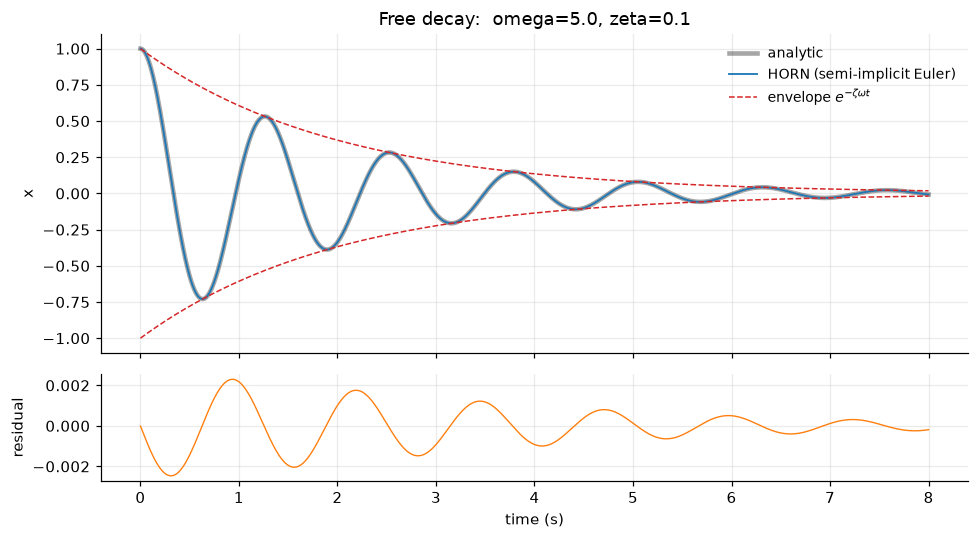

Residual (max |numeric - analytic|) = 2.47e-03
fraction of initial amplitude = 0.25%


In [ ]:
omega, zeta, dt, T = 5.0, 0.1, 1e-3, 8000 # play omegas and zetas

p = make_units(1, omega, zeta)
_, xs = run_sequence(p, at_rest(1, x0=1.0), jnp.zeros((T, 1)), dt)
x_num = np.asarray(xs).ravel()      # calculate the damped harmonic oscillator numerically with HORN

t = time_axis(T, dt)
wd = omega * np.sqrt(1 - zeta**2)  # damped omega solved
x_exact = np.exp(-zeta * omega * t) * (np.cos(wd * t) + (zeta * omega / wd) * np.sin(wd * t)) # exact solution to damped harmonic oscillator

fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1]})
ax[0].plot(t, x_exact, lw=3, alpha=0.35, color="k", label="analytic")
ax[0].plot(t, x_num, lw=1.2, color="C0", label="HORN (semi-implicit Euler)")
ax[0].plot(t, np.exp(-zeta * omega * t), ls="--", lw=1, color="C3", label=r"envelope $e^{-\zeta\omega t}$")
ax[0].plot(t, -np.exp(-zeta * omega * t), ls="--", lw=1, color="C3")
ax[0].set(ylabel="x", title=f"Free decay:  omega={omega}, zeta={zeta}")
ax[0].legend(frameon=False, fontsize=9)

ax[1].plot(t, x_num - x_exact, lw=0.9, color="C1")
ax[1].set(xlabel="time (s)", ylabel="residual")
plt.tight_layout()
plt.show()

print(f"Residual (max |numeric - analytic|) = {np.max(np.abs(x_num - x_exact)):.2e}") # residual is small, but not zero because of numerical error
print(f"fraction of initial amplitude = {np.max(np.abs(x_num - x_exact)) / 1.0:.2%}") # and it is a small fraction of the initial amplitude

The residual comes from integration error and accumulates with $t$ and scales with `dt`. Halving `dt` should halve the error. We can test it:

In [ ]:
print(f"{'dt':>8}  {'steps':>7}  {'max error':>11}   ratio")
prev = None
for dt_i in [4e-3, 2e-3, 1e-3, 5e-4, 2.5e-4]:               # time steps to test convergence
    T_i = int(8.0 / dt_i)
    _, xs_i = run_sequence(make_units(1, omega, zeta), at_rest(1, x0=1.0),
                           jnp.zeros((T_i, 1)), dt_i)
    t_i = time_axis(T_i, dt_i)
    exact_i = np.exp(-zeta * omega * t_i) * (np.cos(wd * t_i) + (zeta * omega / wd) * np.sin(wd * t_i)) # solve for this dt_i
    err = float(np.max(np.abs(np.asarray(xs_i).ravel() - exact_i)))                                     # max error for this dt_i
    ratio = "" if prev is None else f"{prev / err:.2f}x" # ratio is compared to previous, empty string for first iteration
    print(f"{dt_i:>8.1e}  {T_i:>7d}  {err:>11.3e}   {ratio}")
    prev = err

      dt    steps    max error   ratio
 4.0e-03     2000    7.940e-03   
 2.0e-03     4000    3.966e-03   2.00x
 1.0e-03     8000    1.982e-03   2.00x
 5.0e-04    16000    9.908e-04   2.00x
 2.5e-04    32000    4.951e-04   2.00x


Havels the error each time we halve `dt`.

If the error had flattened out, that would mean it was dominated by something else.

## 2. Damping regimes

$\zeta$ is the parameter that makes an oscillator a *memory* rather than just a filter.
It sets how long the ringing survives, so it is the closest thing HORN has to a forget gate,
except it is a physical constant of the unit rather than a learned function of the input.

- $\zeta < 1$ **underdamped**: oscillates, envelope decays as $e^{-\zeta\omega t}$
- $\zeta = 1$ **critically damped**: fastest return to zero with no overshoot
- $\zeta > 1$ **overdamped**: crawls to zero, never crosses it

We have seen this in the demo already, but we can add the tau (time constant):

$$\tau = 1/(\zeta\omega)$$

so the effective memory horizon is set by the *product*. Fast and slow oscillators 
with the same dumping do **not** remember for the same length of time.

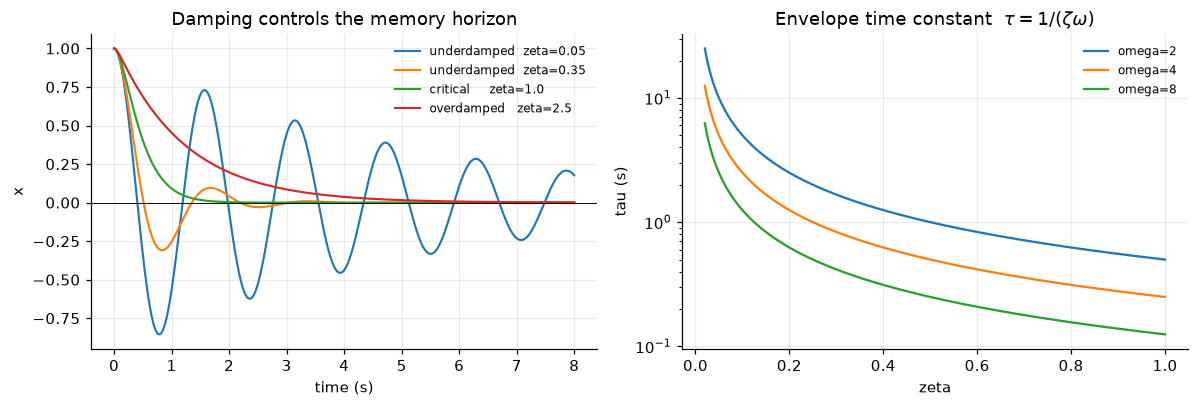

In [5]:
omega, dt, T = 4.0, 1e-3, 8000
t = time_axis(T, dt)
regimes = [(0.05, "underdamped  zeta=0.05"),
           (0.35, "underdamped  zeta=0.35"),
           (1.00, "critical     zeta=1.0"),
           (2.50, "overdamped   zeta=2.5")]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for i, (z, label) in enumerate(regimes):
    _, xs = run_sequence(make_units(1, omega, z), at_rest(1, x0=1.0), jnp.zeros((T, 1)), dt)
    ax[0].plot(t, np.asarray(xs).ravel(), lw=1.4, label=label, color=f"C{i}")
ax[0].axhline(0, color="k", lw=0.6)
ax[0].set(title="Damping controls the memory horizon", xlabel="time (s)", ylabel="x")
ax[0].legend(fontsize=8, frameon=False)

# memory horizon tau = 1/(zeta*omega), only meaningful in the underdamped regime
zs = np.linspace(0.02, 1.0, 200)
for w in [2.0, 4.0, 8.0]:
    ax[1].plot(zs, 1.0 / (zs * w), label=f"omega={w:.0f}")
ax[1].set(title=r"Envelope time constant  $\tau = 1/(\zeta\omega)$",
          xlabel="zeta", ylabel="tau (s)", yscale="log")
ax[1].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## 3. Impulse response

Tha was for the free decay testing.

To test the *drive* we need forcing it, with **impulse**.

A sinlge impulse of $1/\Delta t$ at the first step delivers momentum.
Under semi-implicit Euler this is exactly: 

$$\Delta t \cdot (1/\Delta t) = 1$$

so the unit is kicked to $v = 1$ and then evolves freely. The analytic impulse response is:

$$h(t) = \frac{1}{\omega_d}e^{-\zeta\omega t}\sin(\omega_d t)$$

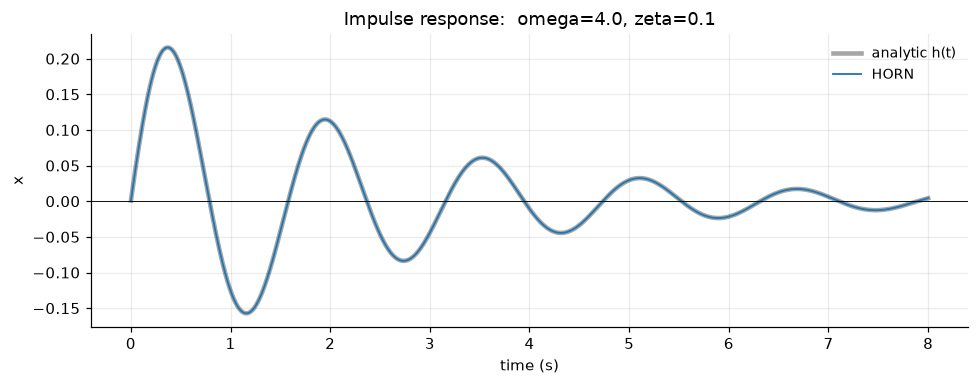

max |numeric - analytic| = 1.83e-04
relative to peak response = 0.08%


In [ ]:
omega, zeta, dt, T = 4.0, 0.10, 1e-3, 8000

u = jnp.zeros((T, 1)).at[0, 0].set(1.0 / dt)      # set up a unit-area impulse at t=0
p = make_units(1, omega, zeta, w_in=1.0)          # w_in=1 -> the input IS the whole impulse term
_, xs = run_sequence(p, at_rest(1), u, dt)
x_num = np.asarray(xs).ravel() # HORN              

t = time_axis(T, dt)
wd = omega * np.sqrt(1 - zeta**2)
h_exact = np.exp(-zeta * omega * t) * np.sin(wd * t) / wd # Exact

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(t, h_exact, lw=3, alpha=0.35, color="k", label="analytic h(t)")
ax.plot(t, x_num, lw=1.2, color="C0", label="HORN")
ax.axhline(0, color="k", lw=0.6)
ax.set(xlabel="time (s)", ylabel="x", title=f"Impulse response:  omega={omega}, zeta={zeta}")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print(f"max |numeric - analytic| = {np.max(np.abs(x_num - h_exact)):.2e}")
print(f"relative to peak response = {np.max(np.abs(x_num - h_exact)) / np.max(np.abs(h_exact)):.2%}")

Therefore *"persistence is free"*. Meanaing that one kick, and the unit
carries a decaying record of it for
$\sim 1/(\zeta\omega) \approx 2.5$ s, 

With nothing that has to be trained to make it happen. NATURALLY.

## 4. Sinusoidal drive and steady state

Now drive them with $u(t) = \sin(\Omega t)$. 

The response splits into a transient (the homogeneous solution, decaying at $e^{-\zeta\omega t}$) 

and a steady state at the *drive* frequency $\Omega$, not the natural frequency:

$$x_{ss}(t) = A(\Omega)\sin(\Omega t - \phi(\Omega)), \qquad
A = \frac{1}{\sqrt{(\omega^2-\Omega^2)^2 + (2\zeta\omega\Omega)^2}}, \qquad
\phi = \arctan\frac{2\zeta\omega\Omega}{\omega^2-\Omega^2}$$

Three drive frequencies: under resonance, at resonance, and above.

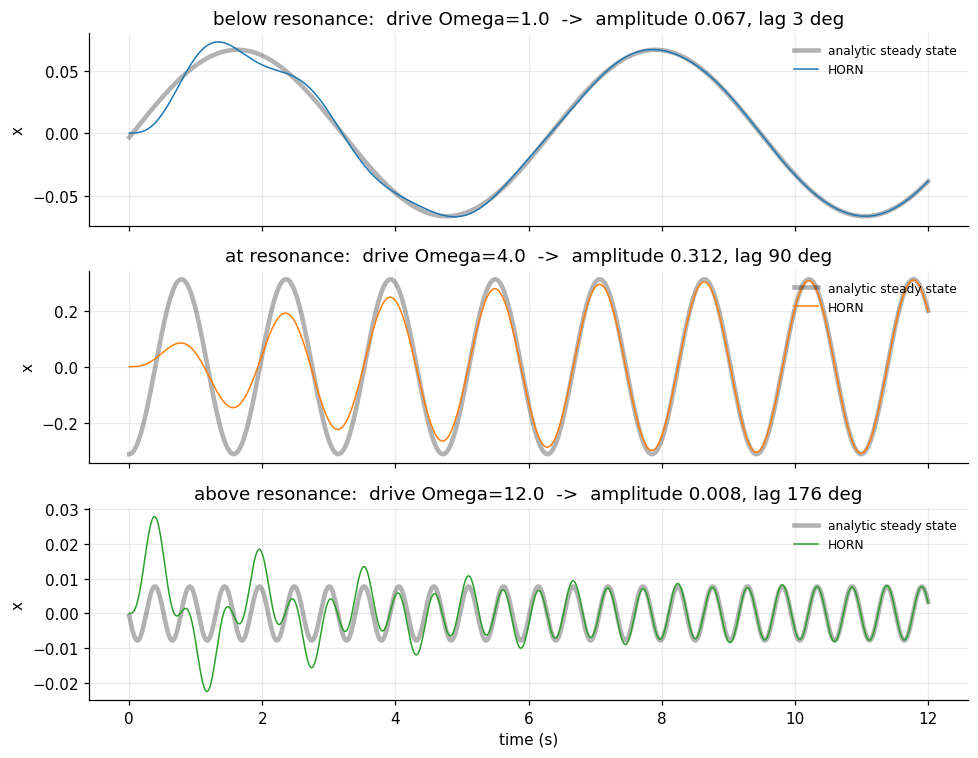

In [ ]:
omega, zeta, dt, T = 4.0, 0.10, 1e-3, 12000 # The unit natural frequency is 4
t = time_axis(T, dt)

def analytic_ss(Om, w0, z):
    A = 1.0 / np.sqrt((w0**2 - Om**2) ** 2 + (2 * z * w0 * Om) ** 2)
    phi = np.arctan2(2 * z * w0 * Om, w0**2 - Om**2)
    return A, phi

drives = [(1.0, "below resonance"), (4.0, "at resonance"), (12.0, "above resonance")] # the drive frequencies to play with
fig, ax = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

for i, (Om, label) in enumerate(drives):
    u = jnp.sin(Om * jnp.arange(1, T + 1) * dt)[:, None]
    _, xs = run_sequence(make_units(1, omega, zeta, w_in=1.0), at_rest(1), u, dt)
    x_num = np.asarray(xs).ravel()

    A, phi = analytic_ss(Om, omega, zeta)
    ax[i].plot(t, A * np.sin(Om * t - phi), lw=3, alpha=0.3, color="k",
               label="analytic steady state")
    ax[i].plot(t, x_num, lw=1.0, color=f"C{i}", label="HORN")
    ax[i].set(ylabel="x", title=f"{label}:  drive Omega={Om}  ->  amplitude {A:.3f}, lag {np.degrees(phi):.0f} deg")
    ax[i].legend(fontsize=8, frameon=False, loc="upper right")

ax[-1].set(xlabel="time (s)")
plt.tight_layout()
plt.show()

Two things:

**The transient is visible only in the first few seconds.** After roughly $5/(\zeta\omega)$ the
numeric trace lies on the analytic solution. That transit time is exactly the memory horizon from before.

**Resonance is a large effect.** At $\Omega = \omega$ the amplitude is $\sim 1/(2\zeta\omega^2)$,
which for $\zeta = 0.1$ is more than an order of magnitude above the off-resonance response.

A unit is selective for its own frequency and that selectivity is what makes them "filters".

## 5. Resonance: amplitude and phase against drive frequency

Sweeping $\Omega$ and measuring the steady-state amplitude gives the unit's transfer function.
This turns "oscillators are frequency selective" into a measurement, where $\zeta$ sets the *width* of the resonance
peak as well as the decay time. 

**Low** $\zeta$ means long memory and narrow tuning.

Amplitude and phase are extracted by projecting the steady-state segment onto $\sin\Omega t$
and $\cos\Omega t$, with a Hann window to suppress spectral leakages.

`jax.vmap` Python loops over separate runs.

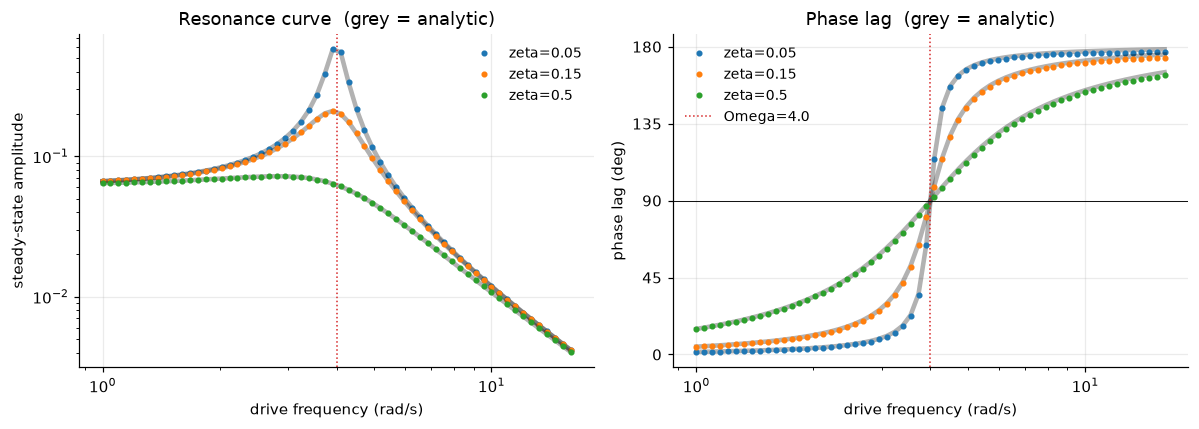

In [ ]:
dt, T = 2e-3, 40000          # 40 s, so even the lowest-zeta transient has fully decayed
omega0 = 4.0                 # modify here the frequency of unit to test
freqs = np.logspace(np.log10(1.0), np.log10(16.0), 60)
tt = np.arange(1, T + 1) * dt

start = T // 2               # measure over the second half only, at steady state
win = np.hanning(T - start)

def measure(zeta):
    p = make_units(1, omega0, zeta, w_in=1.0)
    U = jnp.asarray(np.sin(freqs[:, None] * tt[None, :])[..., None])   # (F, T, 1)
    run = lambda u: run_sequence(p, at_rest(1), u, dt)[1][:, 0]        # -> (T,)
    xs = np.asarray(jax.vmap(run)(U))                                  # (F, T)

    seg, ts = xs[:, start:], tt[start:]
    norm = win.sum()
    s = 2 * np.sum(win * seg * np.sin(freqs[:, None] * ts[None, :]), axis=1) / norm
    c = 2 * np.sum(win * seg * np.cos(freqs[:, None] * ts[None, :]), axis=1) / norm
    return np.hypot(s, c), np.unwrap(np.arctan2(-c, s))   # amplitude, phase lag

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, z in enumerate([0.05, 0.15, 0.50]):                # dumpings to test (zetas)
    amp, phase = measure(z)
    A_ex = 1.0 / np.sqrt((omega0**2 - freqs**2) ** 2 + (2 * z * omega0 * freqs) ** 2)
    phi_ex = np.arctan2(2 * z * omega0 * freqs, omega0**2 - freqs**2)

    ax[0].loglog(freqs, A_ex, lw=3, alpha=0.3, color="k")
    ax[0].loglog(freqs, amp, "o", ms=3, color=f"C{i}", label=f"zeta={z}")
    ax[1].semilogx(freqs, np.degrees(phi_ex), lw=3, alpha=0.3, color="k")
    ax[1].semilogx(freqs, np.degrees(phase), "o", ms=3, color=f"C{i}", label=f"zeta={z}")

ax[0].axvline(omega0, color="C3", ls=":", lw=1), label=f"Omega={omega0}"
ax[0].set(xlabel="drive frequency (rad/s)", ylabel="steady-state amplitude",
          title="Resonance curve  (grey = analytic)")
ax[0].legend(frameon=False, fontsize=9)

ax[1].axvline(omega0, color="C3", ls=":", lw=1, label=f"Omega={omega0}")
ax[1].axhline(90, color="k", lw=0.6)
ax[1].set(xlabel="drive frequency (rad/s)", ylabel="phase lag (deg)",
          title="Phase lag  (grey = analytic)", yticks=[0, 45, 90, 135, 180])
ax[1].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

The phase panel shows something about the state that no conventional RNN has an equivalent for.

Below resonance: the unit follows the drive almost in step.

At $\Omega = \omega$ the lag is exactly $90°$ **for every value of $\zeta$**, damping changes how sharp the transition is, not where it sits.

Above resonance: the unit goes into antiphase, moving opposite to the driver.

So a population with heterogeneous $\omega$ responds to a single input with a *spread of phases*
determined by how each unit's natural frequency compares to the input.

Information is encoded in **relative phase** across the population, **not only in amplitude**.

## 6. A heterogeneous population as a filter bank

Four uncoupled units at $\omega = 2, 4, 8, 16$ driven by a linear chirp sweeping $1 \to 20$ rad/s.
Each unit should light up as the sweep passes its own natural frequency, and fall quiet again
afterwards.

The population collectively performs a time-frequency decomposition of the input, by desig with needing no learning.

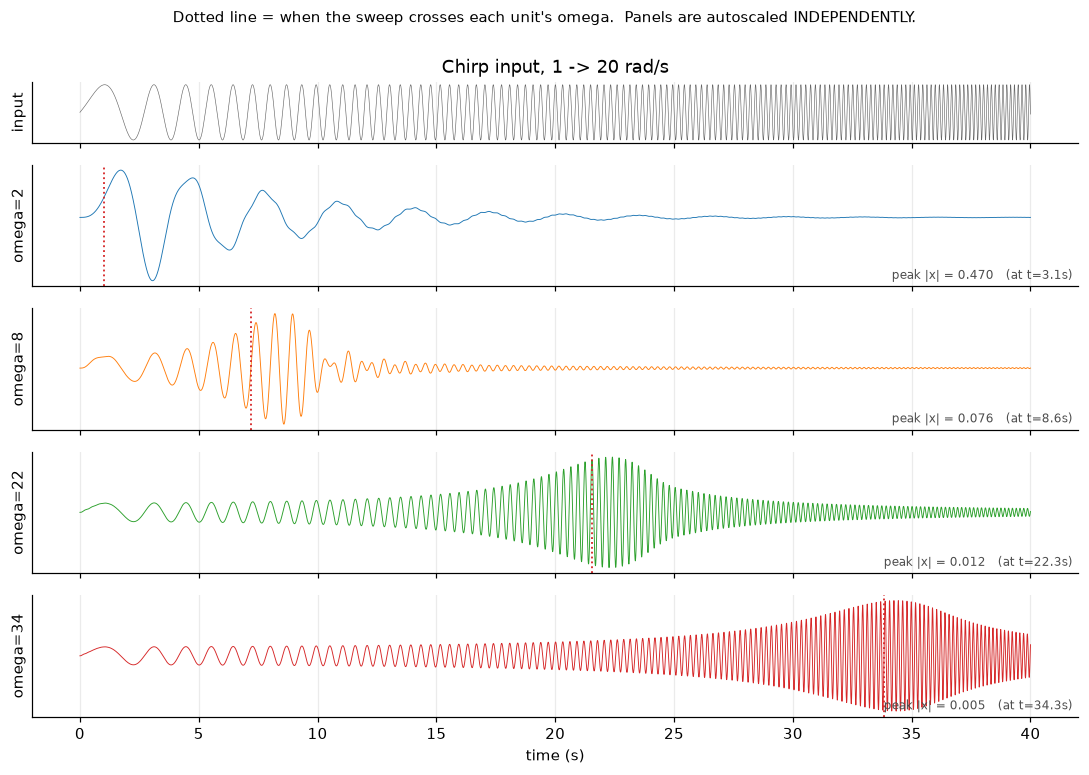

 omega   peak |x|  steady-state   reached  dwell/build-up
     2     0.4701        1.5625      30%            0.05
     8     0.0762        0.0977      78%            0.84
    22     0.0125        0.0129      97%            6.35
    34     0.0054        0.0054      99%           15.18


In [ ]:
dt, T = 1e-3, 40000
t = np.arange(1, T + 1) * dt
f0, f1 = 1.0, 40.0                                 # chirp frequency limits
inst_freq = f0 + (f1 - f0) * t / t[-1]
chirp = np.sin(np.cumsum(inst_freq) * dt)          # phase = integral of instantaneous frequency

omegas = jnp.array([2.0, 8.0, 22.0, 34])           # unit frequencies
p = make_units(4, omegas, 0.08, w_in=1.0)
_, xs = run_sequence(p, at_rest(4), jnp.asarray(chirp)[:, None], dt)
xs = np.asarray(xs)

fig, ax = plt.subplots(5, 1, figsize=(10, 7), sharex=True,
                       gridspec_kw={"height_ratios": [1, 2, 2, 2, 2]})
ax[0].plot(t, chirp, lw=0.4, color="0.4")
ax[0].set(ylabel="input", title="Chirp input, 1 -> 40 rad/s")
ax[0].set_yticks([])

for i, w in enumerate(np.asarray(omegas)):
    ax[i + 1].plot(t, xs[:, i], lw=0.6, color=f"C{i}")
    t_hit = (w - f0) / (f1 - f0) * t[-1]           # when the sweep crosses this unit's omega
    ax[i + 1].axvline(t_hit, color="C3", ls=":", lw=1.2)
    peak = np.max(np.abs(xs[:, i]))
    t_peak = t[np.argmax(np.abs(xs[:, i]))]
    ax[i + 1].set(ylabel=f"omega={w:.0f}")
    ax[i + 1].set_yticks([])
    # NOTE: each panel is autoscaled independently, so the traces look comparable
    # but are not. The annotation gives the true scale.
    ax[i + 1].text(0.995, 0.06, f"peak |x| = {peak:.3f}   (at t={t_peak:.1f}s)",
                   transform=ax[i + 1].transAxes, ha="right", fontsize=8, color="0.3")

ax[-1].set(xlabel="time (s)")
fig.suptitle("Dotted line = when the sweep crosses each unit's omega.  "
             "Panels are autoscaled INDEPENDENTLY.", y=1.0, fontsize=10)
plt.tight_layout()
plt.show()

zeta_c = 0.08
sweep_rate = (f1 - f0) / t[-1]                     # rad/s per second

print(f"{'omega':>6} {'peak |x|':>10} {'steady-state':>13} {'reached':>9} "
      f"{'dwell/build-up':>15}")
for i, w in enumerate(np.asarray(omegas)):
    peak = np.max(np.abs(xs[:, i]))
    ss = 1 / (2 * zeta_c * w**2)                   # steady-state resonant amplitude
    dwell = 2 * zeta_c * w / sweep_rate            # time the sweep spends inside the peak
    build = 1 / (zeta_c * w)                       # time the unit needs to fill up
    print(f"{w:>6.0f} {peak:>10.4f} {ss:>13.4f} {peak / ss:>8.0%} {dwell / build:>15.2f}")

**The peak arrives a bit after unit's omega not on it.** Each unit lags the moment the sweep
crosses its natural frequency, by roughly $1/(\zeta\omega)$. The response is
not a memoryless function of the instantaneous input, it depends on the input's recent
history, and the burst keeps ringing after the sweep has moved on. 

That lag **is** the **memory**, seen in the time domain.

The panels are autoscaled. Slow units have far bigger amplitudes, just like in brains.

**The table is worth reading**. Steady-state resonant amplitude goes as $1/(2\zeta\omega^2)$, which
predicts a 64× spread, not 20×. Every unit falls short of its steady-state value, and the slow
ones fall much further short — $\omega=2$ reaches only about a third of it.

See last column. A sweeping input dwells inside a unit's resonance peak for a time
$\propto \zeta\omega$, while the unit needs $1/(\zeta\omega)$ to fill up. The ratio therefore
scales as $\omega^2$: fast units have time to reach steady state, slow ones never get close.

For next Notebook: with heterogeneous $\omega$, the readout sees mismatched
scales across units, so gradient magnitudes will differ substantially between slow and fast
oscillators. Either $W_{in}$ learns to compensate, or the quiet units are effectively ignored.
Worth testing whether an $\omega$-dependent initialisation of $W_{in}$ fixes it, and whether
sequence length interacts with which units end up useful.

## Conclusion

HORN is verified against closed-form solutions: free decay, impulse response, steady-state amplitude
and phase across frequency. Convergence in `dt` confirmed.

To carry:

1. **`dt` must sit well below the period of the fastest unit.** With heterogeneous $\omega$ the
   constraint is set by $\omega_{max}$, so adding fast units silently raises the cost of every
   sequence. A learned $\omega$ that drifts upward during training can therefore destabilise
   integration without any parameter doing anything obviously wrong.
2. **Response amplitude scales as $1/(2\zeta\omega^2)$.** Fast units are quiet ones. Heterogeneous
   populations start badly scale-mismatched at the readout.
3. **Memory horizon is $1/(\zeta\omega)$, not $1/\zeta$.** Whatever range of memory horizons a
   task needs has to be reachable by the $(\omega, \zeta)$ pairs at initialisation, because
   gradient descent through oscillatory dynamics is not reliable at moving them far.